In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

In [23]:
df = pd.read_csv('/content/sample_data/7817_1.csv.zip')

In [24]:
df.head(2)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams


In [25]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [26]:
df = df[['reviews.text','reviews.title','reviews.rating']]

In [27]:
df.head(5)

,reviews.text,reviews.title,reviews.rating
0,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",5.0
1,Allow me to preface this with a little history...,One Simply Could Not Ask For More,5.0
2,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,4.0
3,I bought one of the first Paperwhites and have...,Love / Hate relationship,5.0
4,I have to say upfront - I don't like coroporat...,I LOVE IT,5.0


In [28]:
df.isnull().sum()

,0
reviews.text,0
reviews.title,17
reviews.rating,420


In [29]:
df = df.dropna()

In [30]:
df.isnull().sum()

,0
reviews.text,0
reviews.title,0
reviews.rating,0


In [31]:
df = df[df['reviews.rating'] != 3]

df['sentiment'] = df['reviews.rating'].apply(lambda x: 1 if x >= 4 else 0)

In [32]:
df['review'] = df['reviews.title'] + " " + df['reviews.text']

In [33]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

df['review'] = df['review'].apply(clean_text)

In [34]:


tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['review'])
y = df['sentiment']

In [36]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:


model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9383886255924171
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.94      1.00      0.97       198

    accuracy                           0.94       211
   macro avg       0.47      0.50      0.48       211
weighted avg       0.88      0.94      0.91       211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


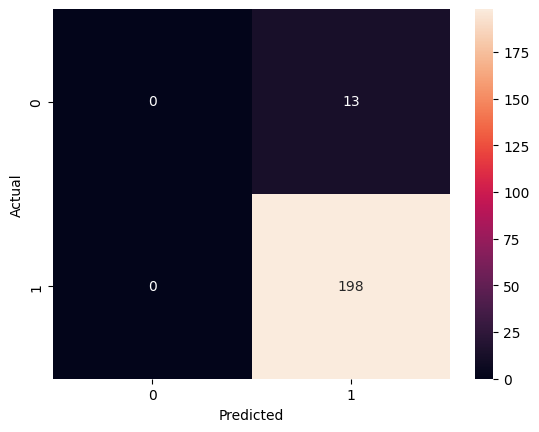

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
new_review = ["This product is amazing and works perfectly"]

new_review_vec = tfidf.transform(new_review)

prediction = model.predict(new_review_vec)

print(prediction)

[1]


In [47]:
if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
